In [2]:
import pandas as pd

df = pd.read_csv("youtube_ad_revenue_dataset.csv")
df.head()        
    

,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd
0,vid_3092,2024-09-24 10:50:40.993199,9936,1221.0,320.0,26497.214184,2.862137,228086,Entertainment,TV,IN,203.178237
1,vid_3459,2024-09-22 10:50:40.993199,10017,642.0,346.0,15209.747445,23.738069,736015,Gaming,Tablet,CA,140.880508
2,vid_4784,2024-11-21 10:50:40.993199,10097,1979.0,187.0,57332.658498,26.200634,240534,Education,TV,CA,360.134008
3,vid_4078,2025-01-28 10:50:40.993199,10034,1191.0,242.0,31334.517771,11.770340,434482,Entertainment,Mobile,UK,224.638261
4,vid_3522,2025-04-28 10:50:40.993199,9889,1858.0,477.0,15665.666434,6.635854,42030,Education,Mobile,CA,165.514388


In [3]:
df.shape

(122400, 12)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122400 entries, 0 to 122399
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   video_id              122400 non-null  object 
 1   date                  122400 non-null  object 
 2   views                 122400 non-null  int64  
 3   likes                 116283 non-null  float64
 4   comments              116288 non-null  float64
 5   watch_time_minutes    116295 non-null  float64
 6   video_length_minutes  122400 non-null  float64
 7   subscribers           122400 non-null  int64  
 8   category              122400 non-null  object 
 9   device                122400 non-null  object 
 10  country               122400 non-null  object 
 11  ad_revenue_usd        122400 non-null  float64
dtypes: float64(5), int64(2), object(5)
memory usage: 11.2+ MB


In [5]:
df.isnull().sum()

video_id                   0
date                       0
views                      0
likes                   6117
comments                6112
watch_time_minutes      6105
video_length_minutes       0
subscribers                0
category                   0
device                     0
country                    0
ad_revenue_usd             0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(2400)

In [7]:
df.describe()

,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,ad_revenue_usd
count,122400.000000,116283.000000,116288.000000,116295.000000,122400.000000,122400.000000,122400.000000
mean,9999.856283,1099.633618,274.396636,37543.827721,16.014165,502191.719902,252.727210
std,99.881260,519.424089,129.741739,12987.724246,8.083790,288397.470103,61.957052
min,9521.000000,195.000000,48.000000,14659.105562,2.000142,1005.000000,126.590603
25%,9933.000000,650.000000,162.000000,26366.320569,9.004695,252507.500000,199.902018
50%,10000.000000,1103.000000,274.000000,37531.990337,16.005906,503465.500000,252.749699
75%,10067.000000,1547.000000,387.000000,48777.782090,23.021260,752192.000000,305.597518
max,10468.000000,2061.000000,515.000000,61557.670089,29.999799,999997.000000,382.768254


In [8]:
print(df['category'].value_counts())
print("---")
print(df['device'].value_counts())
print("---")
print(df['country'].value_counts())

category
Education        20514
Music            20475
Tech             20444
Entertainment    20411
Gaming           20359
Lifestyle        20197
Name: count, dtype: int64
---
device
TV         30646
Mobile     30598
Tablet     30579
Desktop    30577
Name: count, dtype: int64
---
country
CA    20603
DE    20582
IN    20564
AU    20313
UK    20269
US    20069
Name: count, dtype: int64


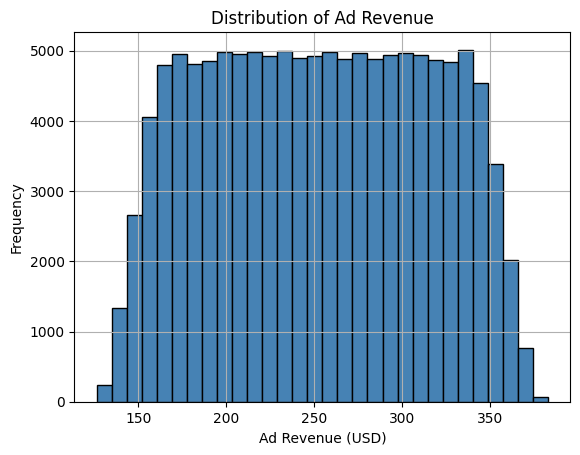

In [9]:
import matplotlib.pyplot as plt

df['ad_revenue_usd'].hist(bins=30, color='steelblue', edgecolor='black')
plt.title('Distribution of Ad Revenue')
plt.xlabel('Ad Revenue (USD)')
plt.ylabel('Frequency')
plt.show()

In [10]:
df.corr(numeric_only=True)['ad_revenue_usd'].sort_values(ascending=False)

ad_revenue_usd          1.000000
watch_time_minutes      0.988874
likes                   0.146449
views                   0.038497
comments                0.034274
subscribers             0.005907
video_length_minutes   -0.000446
Name: ad_revenue_usd, dtype: float64

In [11]:
## Key Insight
##  - watch_time_minutes has 0.989 correlation with ad_revenue — strongest predictor
##  - views, subscribers, video_length have almost no correlation with revenue

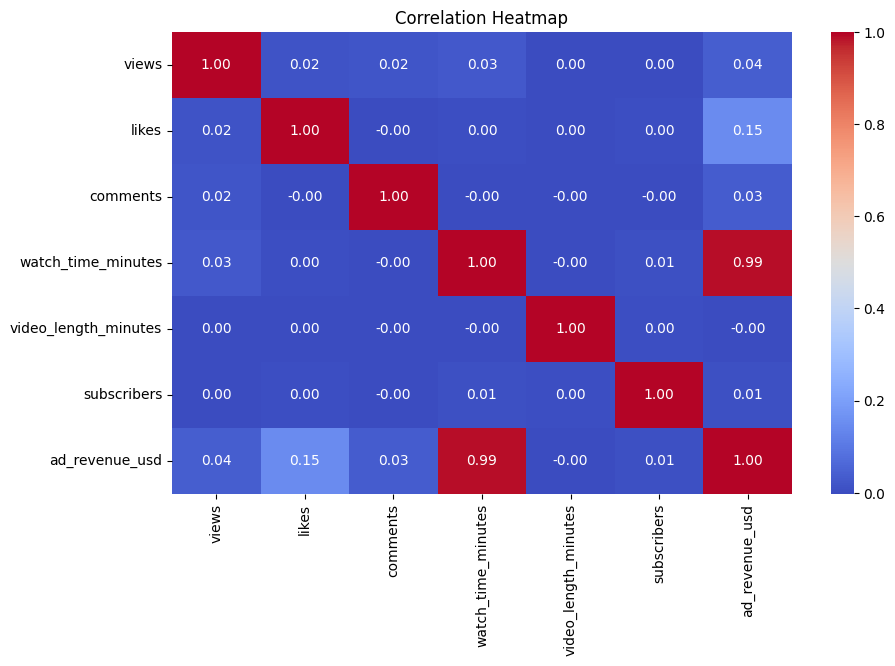

In [12]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [13]:
# Handling the DUPLICATE VALUES

In [14]:
# Check shape before
print("Before removing duplicates:", df.shape)

# Remove duplicates
df = df.drop_duplicates()

# Check shape after
print("After removing duplicates:", df.shape)

Before removing duplicates: (122400, 12)
After removing duplicates: (120000, 12)


In [15]:
# HANDLING THE MISSING VALUES IN THREE COLUMNS 

In [16]:
# Check missing values before
print("Missing values BEFORE:")
print(df.isnull().sum())

Missing values BEFORE:
video_id                   0
date                       0
views                      0
likes                   6000
comments                6000
watch_time_minutes      6000
video_length_minutes       0
subscribers                0
category                   0
device                     0
country                    0
ad_revenue_usd             0
dtype: int64


In [17]:
# Fill missing values with median of each column
df['likes'] = df['likes'].fillna(df['likes'].median())
df['comments'] = df['comments'].fillna(df['comments'].median())
df['watch_time_minutes'] = df['watch_time_minutes'].fillna(df['watch_time_minutes'].median())

In [18]:
# Check missing values after
print("\nMissing values AFTER:")
print(df.isnull().sum())


Missing values AFTER:
video_id                0
date                    0
views                   0
likes                   0
comments                0
watch_time_minutes      0
video_length_minutes    0
subscribers             0
category                0
device                  0
country                 0
ad_revenue_usd          0
dtype: int64


In [19]:
#Feature Engineering

In [20]:
# Create engagement rate feature
df['engagement_rate'] = (df['likes'] + df['comments']) / df['views']

In [21]:
# Check it was created correctly
print(df[['views', 'likes', 'comments', 'engagement_rate']].head())
print("\nEngagement rate stats:")
print(df['engagement_rate'].describe())

   views   likes  comments  engagement_rate
0   9936  1221.0     320.0         0.155093
1  10017   642.0     346.0         0.098632
2  10097  1979.0     187.0         0.214519
3  10034  1191.0     242.0         0.142814
4   9889  1858.0     477.0         0.236121

Engagement rate stats:
count    120000.000000
mean          0.137410
std           0.052160
min           0.025492
25%           0.094965
50%           0.137501
75%           0.179921
max           0.249554
Name: engagement_rate, dtype: float64


In [22]:
# Drop Useless Columns

In [23]:
# Drop columns that won't help the model
df = df.drop(columns=['video_id', 'date'])

# Confirm they're gone
print(df.columns.tolist())
print(df.shape)

['views', 'likes', 'comments', 'watch_time_minutes', 'video_length_minutes', 'subscribers', 'category', 'device', 'country', 'ad_revenue_usd', 'engagement_rate']
(120000, 11)


In [24]:
#  Encoding Categorical Columns
# One-Hot Encoding

In [25]:
# One-hot encode categorical columns
df = pd.get_dummies(df, columns=['category', 'device', 'country'])

# Check new shape and columns
print("New shape:", df.shape)
print("\nNew columns:", df.columns.tolist())

New shape: (120000, 24)

New columns: ['views', 'likes', 'comments', 'watch_time_minutes', 'video_length_minutes', 'subscribers', 'ad_revenue_usd', 'engagement_rate', 'category_Education', 'category_Entertainment', 'category_Gaming', 'category_Lifestyle', 'category_Music', 'category_Tech', 'device_Desktop', 'device_Mobile', 'device_TV', 'device_Tablet', 'country_AU', 'country_CA', 'country_DE', 'country_IN', 'country_UK', 'country_US']


In [26]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop(columns=['ad_revenue_usd'])
y = df['ad_revenue_usd']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [27]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (96000, 23)
X_test shape: (24000, 23)
y_train shape: (96000,)
y_test shape: (24000,)


In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Create the model
lr_model = LinearRegression()

# Train the model
lr_model.fit(X_train, y_train)

# Predict on test set
y_pred_lr = lr_model.predict(X_test)

# Evaluate
r2   = r2_score(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae  = mean_absolute_error(y_test, y_pred_lr)

print("Linear Regression Results:")
print(f"R²   : {r2:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")

Linear Regression Results:
R²   : 0.9526
RMSE : 13.4806
MAE  : 3.1119


In [29]:
from sklearn.linear_model import Ridge

# Create the model
ridge_model = Ridge(alpha=1.0)  # 1.0 is the default penalty

# Train the model
ridge_model.fit(X_train, y_train)

# Predict on test set
y_pred_ridge = ridge_model.predict(X_test)

# Evaluate
r2   = r2_score(y_test, y_pred_ridge)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
mae  = mean_absolute_error(y_test, y_pred_ridge)

print("Ridge Regression Results:")
print(f"R²   : {r2:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")

Ridge Regression Results:
R²   : 0.9526
RMSE : 13.4798
MAE  : 3.1071


c:\Users\craj1\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.2521843919343427e-16.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


In [30]:
from sklearn.tree import DecisionTreeRegressor

# Create the model
dt_model = DecisionTreeRegressor(max_depth=10, random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

# Predict on test set
y_pred_dt = dt_model.predict(X_test)

# Evaluate
r2   = r2_score(y_test, y_pred_dt)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_dt))
mae  = mean_absolute_error(y_test, y_pred_dt)

print("Decision Tree Results:")
print(f"R²   : {r2:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")

Decision Tree Results:
R²   : 0.9499
RMSE : 13.8542
MAE  : 4.2311


In [31]:
from sklearn.ensemble import RandomForestRegressor

# Create the model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model (this will take 1-2 minutes - normal!)
print("Training Random Forest... please wait")
rf_model.fit(X_train, y_train)

# Predict on test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate
r2   = r2_score(y_test, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae  = mean_absolute_error(y_test, y_pred_rf)

print("Random Forest Results:")
print(f"R²   : {r2:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")

Training Random Forest... please wait
Random Forest Results:
R²   : 0.9499
RMSE : 13.8563
MAE  : 3.5872


In [32]:
from sklearn.ensemble import GradientBoostingRegressor

# Create the model
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# Train the model (may take 1-2 minutes)
print("Training Gradient Boosting... please wait")
gb_model.fit(X_train, y_train)

# Predict on test set
y_pred_gb = gb_model.predict(X_test)

# Evaluate
r2   = r2_score(y_test, y_pred_gb)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb))
mae  = mean_absolute_error(y_test, y_pred_gb)

print("Gradient Boosting Results:")
print(f"R²   : {r2:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")

Training Gradient Boosting... please wait
Gradient Boosting Results:
R²   : 0.9523
RMSE : 13.5249
MAE  : 3.6163


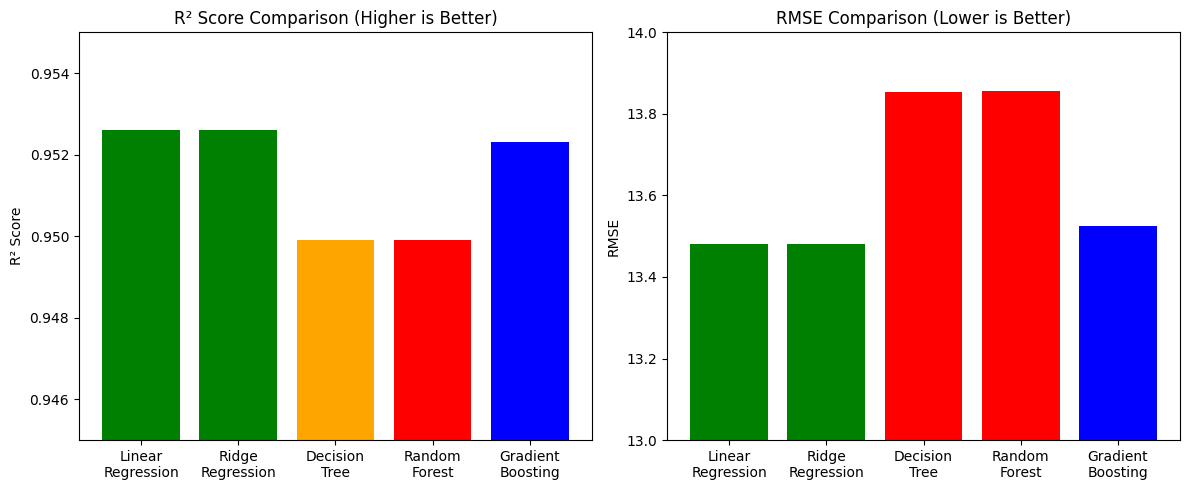

In [33]:
# Compare all models in a bar chart
models_names = ['Linear\nRegression', 'Ridge\nRegression', 
                'Decision\nTree', 'Random\nForest', 'Gradient\nBoosting']

r2_scores = [0.9526, 0.9526, 0.9499, 0.9499, 0.9523]
rmse_scores = [13.4806, 13.4798, 13.8542, 13.8563, 13.5249]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# R² comparison
ax1.bar(models_names, r2_scores, color=['green','green','orange','red','blue'])
ax1.set_title('R² Score Comparison (Higher is Better)')
ax1.set_ylabel('R² Score')
ax1.set_ylim(0.945, 0.955)

# RMSE comparison
ax2.bar(models_names, rmse_scores, color=['green','green','red','red','blue'])
ax2.set_title('RMSE Comparison (Lower is Better)')
ax2.set_ylabel('RMSE')
ax2.set_ylim(13.0, 14.0)

plt.tight_layout()
plt.show()

In [34]:
import pickle

# Save the best model (Ridge Regression)
with open('best_model.pkl', 'wb') as f:
    pickle.dump(ridge_model, f)

# Save the column names too (needed for prediction)
with open('model_columns.pkl', 'wb') as f:
    pickle.dump(X_train.columns.tolist(), f)

print("Model saved successfully!")
print("Columns saved:", X_train.columns.tolist())

Model saved successfully!
Columns saved: ['views', 'likes', 'comments', 'watch_time_minutes', 'video_length_minutes', 'subscribers', 'engagement_rate', 'category_Education', 'category_Entertainment', 'category_Gaming', 'category_Lifestyle', 'category_Music', 'category_Tech', 'device_Desktop', 'device_Mobile', 'device_TV', 'device_Tablet', 'country_AU', 'country_CA', 'country_DE', 'country_IN', 'country_UK', 'country_US']
